In [30]:
"""
Name: Module 6 Academic Success.py
Course: Data Preparation and Analysis
Created Date: November 4, 2023
Author: Ming-Long Lam, Ph.D.g
Organization: Illinois Institute of Technology
"""

'\nName: Module 6 Academic Success.py\nCourse: Data Preparation and Analysis\nCreated Date: November 4, 2023\nAuthor: Ming-Long Lam, Ph.D.g\nOrganization: Illinois Institute of Technology\n'

In [31]:
import matplotlib.pyplot as plt
import numpy
import pandas
import sys

In [32]:
from scipy.stats import chi2

In [33]:
import os

# Find CSP571 folder by walking up from cwd
cwd = os.path.abspath(os.getcwd())
search_dir = cwd
base_dir = None
for _ in range(5):
    candidate = os.path.join(search_dir, "CSP571")
    if os.path.isdir(candidate) and os.path.isfile(os.path.join(candidate, "raw", "Utility.py")):
        base_dir = candidate
        break
    search_dir = os.path.dirname(search_dir)

if base_dir is None:
    raise FileNotFoundError("Could not locate CSP571/raw/Utility.py from current working directory.")

sys.path.append(os.path.join(base_dir, "raw"))
import Utility

In [34]:
# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)

In [35]:
pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)

In [36]:
pandas.options.display.float_format = '{:,.10f}'.format

In [ ]:
face = pandas.read_csv(r'data\Face.csv')
face.head()

# Create binary target for nose vs non-nose
face = face.copy()
face["IS_NOSE"] = (face["feature"].astype(int) == 3).astype(int)

print(face["IS_NOSE"].value_counts())
face.drop(columns=["feature"], inplace=True)
face.info()

In [37]:
success = pandas.read_csv(r'data\Student Academic Success.csv', delimiter = ';') 
success.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.0000000000,0,0,0,0,0,0.0000000000,0,10.8000000000,1.4000000000,1.7400000000,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.0000000000,0,0,6,6,6,13.6666666667,0,13.9000000000,-0.3000000000,0.7900000000,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.0000000000,0,0,6,0,0,0.0000000000,0,10.8000000000,1.4000000000,1.7400000000,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.4285714286,0,0,6,10,5,12.4000000000,0,9.4000000000,-0.8000000000,-3.1200000000,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.3333333333,0,0,6,6,6,13.0000000000,0,13.9000000000,-0.3000000000,0.7900000000,Graduate


In [38]:
print(success.groupby('Target').size())

Target
Dropout     1421
Enrolled     794
Graduate    2209
dtype: int64


In [39]:
success['Dropout'] = success['Target'].map({'Dropout': 'Yes', 'Enrolled': 'No', 'Graduate': 'No'})
q_dropout_count = success.groupby('Dropout').size()
q_dropout_odds = q_dropout_count['Yes'] / q_dropout_count['No']

In [40]:
success['Attendance'] = success['Daytime/evening attendance'].map({0: 'Evening', 1: 'Daytime'})
success['Debtor'] = success['Debtor'].map({0: 'No', 1: 'Yes'})
success['Scholarship holder'] = success['Scholarship holder'].map({0: 'No', 1: 'Yes'})

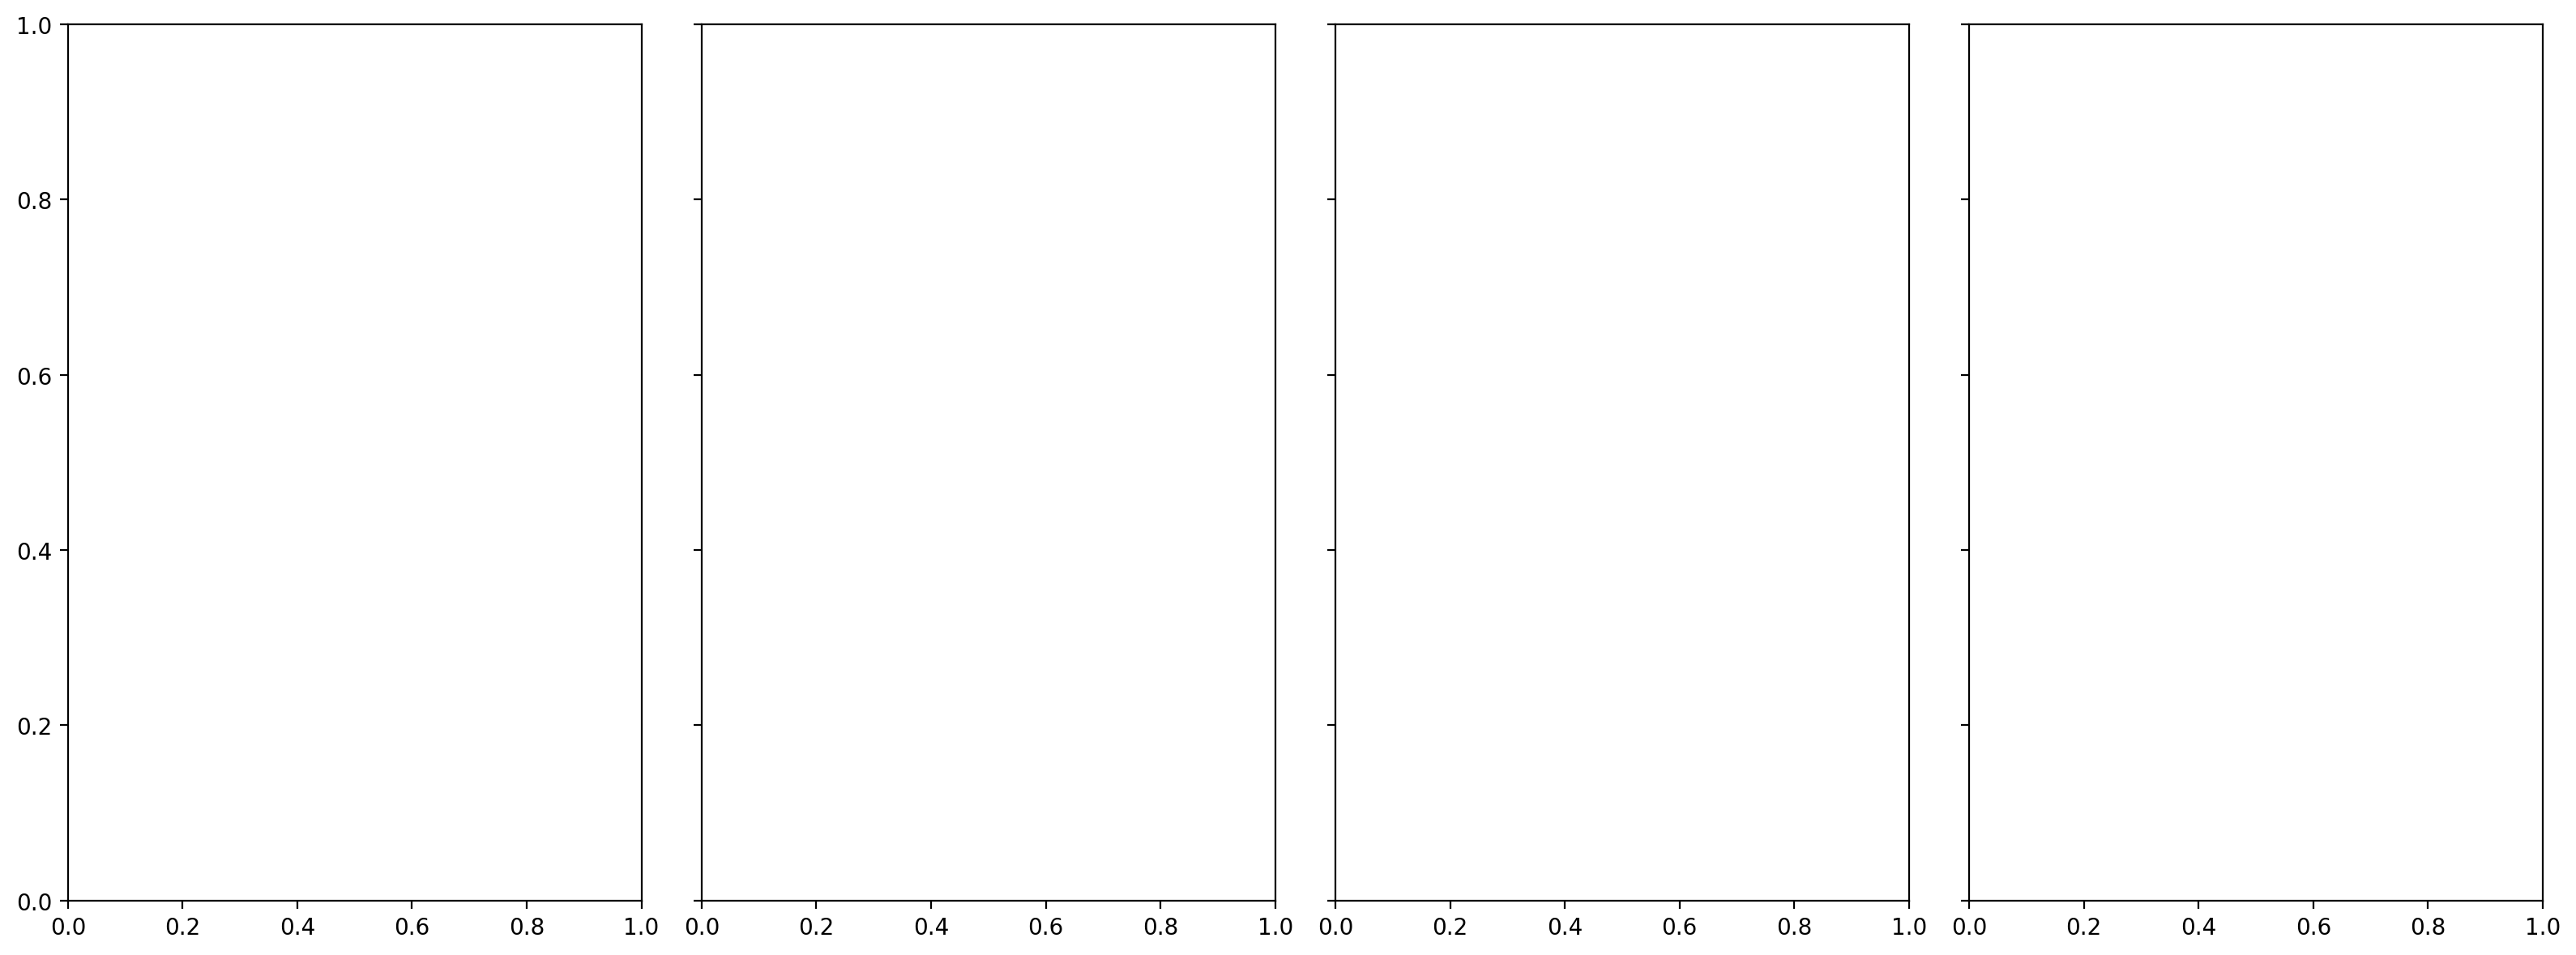

In [41]:
# Univariate frequency bar charts
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows = 1, ncols = 4, dpi = 200, sharey = True, figsize = (16,6))
fig.tight_layout()

In [42]:
ufreq = success['Dropout'].astype('category').value_counts()
ax1.bar(ufreq.index, ufreq, color = 'red')
ax1.set_xlabel('Drop Out College?')
ax1.set_ylabel('Number of Observations')
ax1.set_yticks(range(0, 4500, 500))
ax1.yaxis.grid(True)

In [43]:
ufreq = success['Attendance'].astype('category').value_counts()
ax2.bar(ufreq.index, ufreq, color = 'dodgerblue')
ax2.set_xlabel('Mode of Attendance')
ax2.set_ylabel('')
ax2.yaxis.grid(True)

In [44]:
ufreq = success['Debtor'].astype('category').value_counts()
ax3.bar(ufreq.index, ufreq, color = 'orange')
ax3.set_xlabel('Owe Debt?')
ax3.set_ylabel('')
ax3.yaxis.grid(True)

In [45]:
ufreq = success['Scholarship holder'].astype('category').value_counts()
ax4.bar(ufreq.index, ufreq, color = 'green')
ax4.set_xlabel('Hold Scholarship?')
ax4.set_ylabel('')
ax4.yaxis.grid(True)

In [46]:
plt.show()

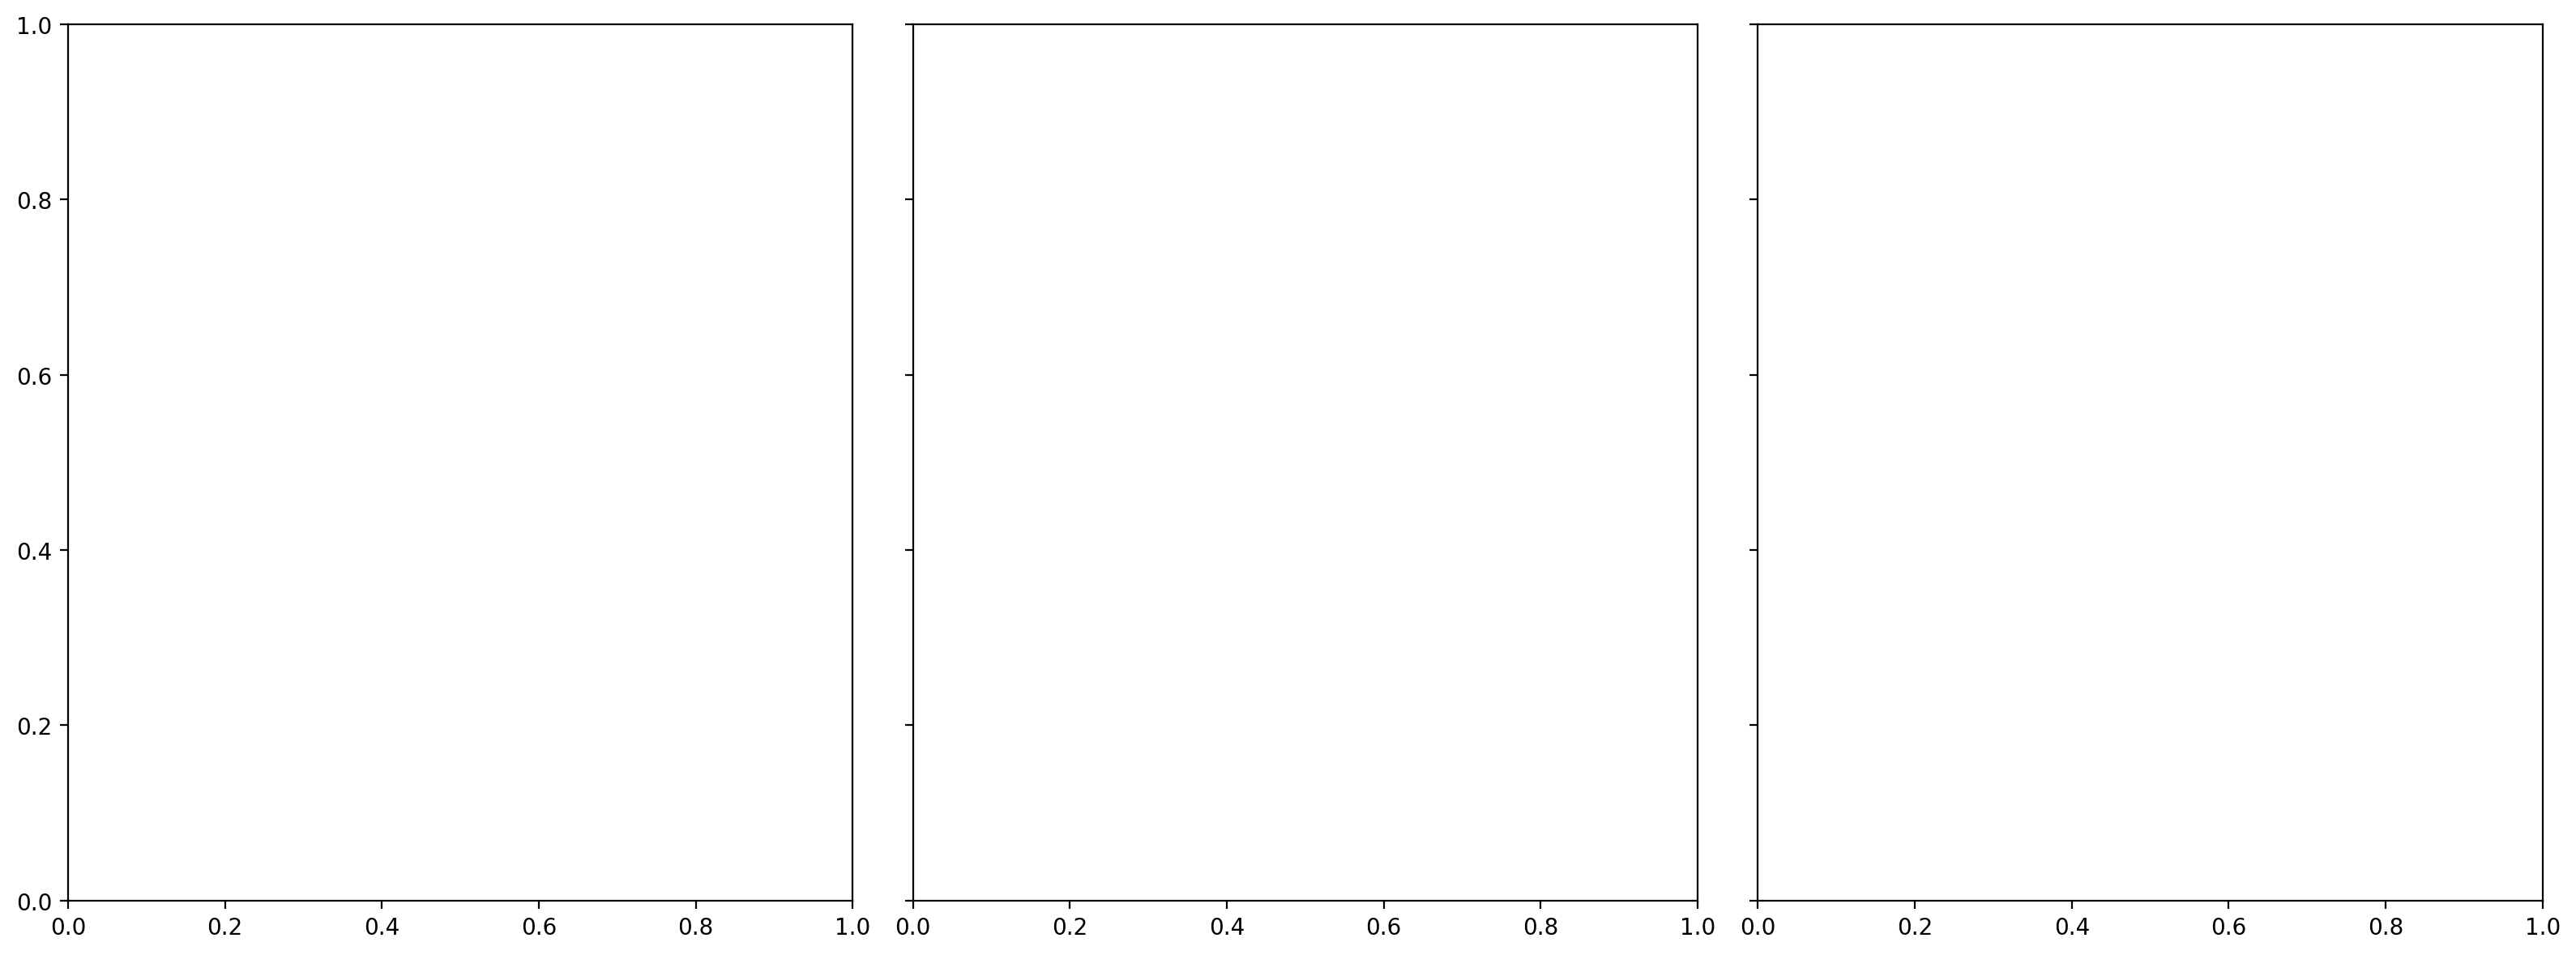

In [47]:
# Univariate odds of dropout
fig, (ax1, ax2, ax3) = plt.subplots(nrows = 1, ncols = 3, dpi = 200, sharey = True, figsize = (16,6))
fig.tight_layout()

In [48]:
xtab = pandas.crosstab(success['Attendance'], success['Dropout'])
odds_table =  xtab['Yes'] / xtab['No']

In [49]:
ax1.bar(odds_table.index, odds_table, color = 'dodgerblue')
ax1.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
ax1.set_xlabel('Mode of Attendance')
ax1.set_ylabel('Dropout Odds = Yes/No')
ax1.yaxis.grid(True)

In [50]:
xtab = pandas.crosstab(success['Debtor'], success['Dropout'])
odds_table =  xtab['Yes'] / xtab['No']

In [51]:
ax2.bar(odds_table.index, odds_table, color = 'orange')
ax2.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
ax2.set_xlabel('Owe Debt?')
ax2.set_ylabel('')
ax2.yaxis.grid(True)

In [52]:
xtab = pandas.crosstab(success['Scholarship holder'], success['Dropout'])
odds_table =  xtab['Yes'] / xtab['No']

In [53]:
ax3.bar(odds_table.index, odds_table, color = 'green')
ax3.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
ax3.set_xlabel('Hold Scholarship?')
ax3.set_ylabel('')
ax3.yaxis.grid(True)

In [54]:
plt.show()

In [55]:
xtab = pandas.crosstab(success['Age at enrollment'], success['Dropout'])
print(xtab)

Dropout             No  Yes
Age at enrollment          
17                   5    0
18                 834  202
19                 704  207
20                 466  133
21                 229   93
22                 116   58
23                  67   41
24                  75   56
25                  46   47
26                  42   52
27                  36   55
28                  36   47
29                  21   45
30                  19   30
31                  19   36
32                  28   33
33                  25   20
34                  31   29
35                  20   29
36                  14   21
37                  19   23
38                  10   19
39                  20   18
40                  10   13
41                  20   11
42                   6    7
43                  14   11
44                  11   10
45                   9   13
46                   6    6
47                   7   11
48                   4    7
49                   6    7
50                  

In [56]:
odds_table =  xtab['Yes'] / xtab['No']

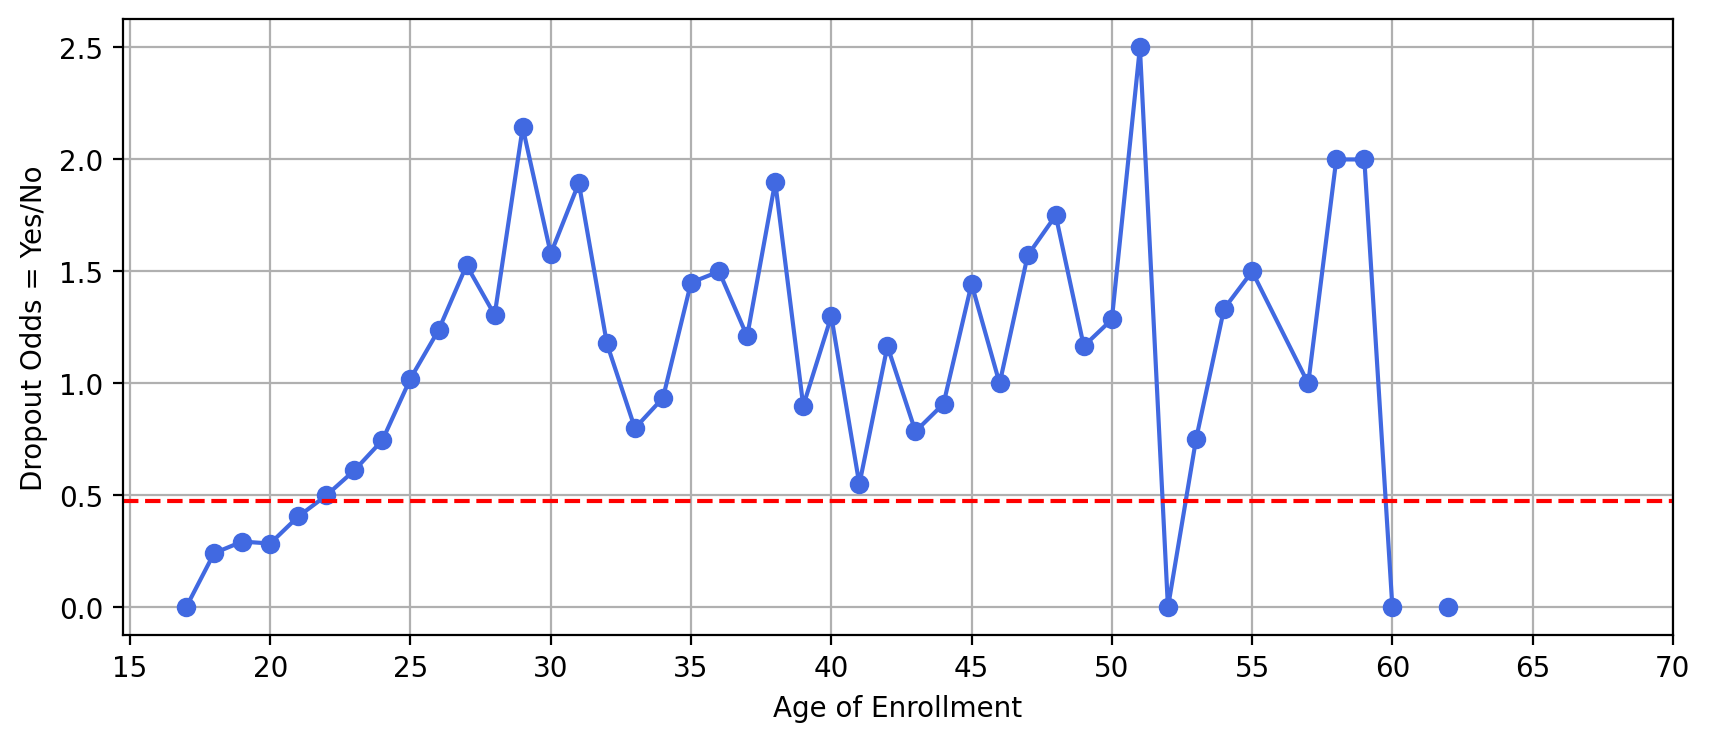

In [57]:
plt.figure(figsize = (10,4), dpi = 200)
plt.plot(odds_table.index, odds_table, marker = 'o', color = 'royalblue')
plt.axhline(y = q_dropout_odds, color = 'red', linestyle = '--')
plt.xlabel('Age of Enrollment')
plt.ylabel('Dropout Odds = Yes/No')
plt.xticks(numpy.arange(15,75,5))
plt.grid(axis = 'both')
plt.show()

In [58]:
# Forward Selection
catName = ['Attendance', 'Debtor', 'Scholarship holder']
intName = ['Age at enrollment']
yName = 'Dropout'
yCat = ['No', 'Yes']

In [59]:
train_data = success[catName + intName + [yName]]

In [60]:
step_diary = []
y_train = train_data[yName]

In [61]:
# Intercept only model
X0_train = train_data[[]].copy()
X0_train.insert(0, 'Intercept', 1.0)

In [62]:
result_list = Utility.MNLogisticModel (X0_train, y_train)
n_iter = result_list[0].mle_retvals['iterations']
llk0 = result_list[1]
df0 = result_list[2]

Optimization terminated successfully.
         Current function value: 0.627773
         Iterations 4


In [63]:
step_diary.append([0, 'Intercept', ' ', n_iter, df0, llk0, numpy.nan, numpy.nan, numpy.nan])

In [64]:
entryThreshold = 0.05

In [65]:
cName = catName.copy()
iName = intName.copy()
nPredictor = len(cName) + len(iName)

In [66]:
# The Deviance significance is the eighth element in each row of the test result
def takeDevSig(s):
    return s[7]

In [67]:
for step in range(nPredictor):
    enterName = ''

    # Columns are 'Predictor', 'Type', 'N Iter', 'ModelDF', 'ModelLLK', 'DevChiSq', 'DevDF', 'DevSig'
    step_detail = []

    # Enter the next predictor
    for X_name in cName:
        X_train = X0_train.join(pandas.get_dummies(train_data[[X_name]].astype('category'), dtype = float))
        result_list = Utility.MNLogisticModel (X_train, y_train)
        n_iter = result_list[0].mle_retvals['iterations']
        llk1 = result_list[1]
        df1 = result_list[2]
        devChiSq = 2.0 * (llk1 - llk0)
        devDF = df1 - df0
        devSig = chi2.sf(devChiSq, devDF)
        step_detail.append([X_name, 'categorical', n_iter, df1, llk1, devChiSq, devDF, devSig])

    for X_name in iName:
        X_train = X0_train.join(train_data[[X_name]])
        result_list = Utility.MNLogisticModel (X_train, y_train)
        n_iter = result_list[0].mle_retvals['iterations']
        llk1 = result_list[1]
        df1 = result_list[2]
        devChiSq = 2.0 * (llk1 - llk0)
        devDF = df1 - df0
        devSig = chi2.sf(devChiSq, devDF)
        step_detail.append([X_name, 'interval', n_iter, df1, llk1, devChiSq, devDF, devSig])

    # Find a predictor to add, if any
    step_detail.sort(key = takeDevSig, reverse = False)
    minSig = takeDevSig(step_detail[0])
    if (minSig <= entryThreshold):
        add_var = step_detail[0][0]
        add_type = step_detail[0][1]
        df0 = step_detail[0][3]
        llk0 = step_detail[0][4]
        step_diary.append([step+1] + step_detail[0])
        if (add_type == 'categorical'):
           X0_train = X0_train.join(pandas.get_dummies(train_data[[add_var]].astype('category'), dtype = float))
           cName.remove(add_var)
        else:
           X0_train = X0_train.join(train_data[[add_var]])
           iName.remove(add_var)           
    else:
        break

Optimization terminated successfully.
         Current function value: 0.624665
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.603379
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.593721
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.597097
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.592099
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.571697
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.572282
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.569812
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.552984
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.552509
  

In [68]:
# End of forward selection
print('\n======= Step Summary =======')
step_diary = pandas.DataFrame(step_diary, columns = ['Step', 'Predictor', 'Type', 'N Iter', 'ModelDF', \
                              'ModelLLK', 'DevChiSq', 'DevDF', 'DevSig'])
print(step_diary)


======= Step Summary =======
   Step           Predictor         Type  N Iter  ModelDF          ModelLLK       DevChiSq        DevDF       DevSig
0     0           Intercept                    4        1 -2,777.2658559465            NaN          NaN          NaN
1     1  Scholarship holder  categorical       5        2 -2,626.6211940628 301.2893237673 1.0000000000 0.0000000000
2     2              Debtor  categorical       6        3 -2,529.1858155592 194.8707570073 1.0000000000 0.0000000000
3     3   Age at enrollment     interval       6        4 -2,446.4033618084 165.5649075016 1.0000000000 0.0000000000
4     4          Attendance  categorical       6        5 -2,444.2981338310   4.2104559547 1.0000000000 0.0401755367


In [69]:
# Retrain the final model
result_list = Utility.MNLogisticModel (X0_train, y_train)
thisFit = result_list[0]

Optimization terminated successfully.
         Current function value: 0.552509
         Iterations 6


In [70]:
print(thisFit.summary())

                          MNLogit Regression Results                          
Dep. Variable:                Dropout   No. Observations:                 4424
Model:                        MNLogit   Df Residuals:                     4419
Method:                           MLE   Df Model:                            4
Date:                Sat, 21 Feb 2026   Pseudo R-squ.:                  0.1199
Time:                        10:15:01   Log-Likelihood:                -2444.3
converged:                       True   LL-Null:                       -2777.3
Covariance Type:            nonrobust   LLR p-value:                8.273e-143
          Dropout=Yes       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -2.3410      0.233    -10.034      0.000      -2.798      -1.884
Scholarship holder_No     1.3392      0.102     13.077      0.000       1.138       1.540
Debtor_N

In [71]:
beta =  thisFit.params
aliasParam = result_list[4]
nonAliasParam = result_list[5]

In [72]:
print('=== Aliased Columns in Model Matrix X ===')
print(X0_train.columns[aliasParam])

=== Aliased Columns in Model Matrix X ===
Index(['Scholarship holder_Yes', 'Debtor_Yes', 'Attendance_Evening'], dtype='object')


In [73]:
llk1 = thisFit.llf
llk0 = thisFit.llnull
n_sample = X0_train.shape[0]

In [74]:
R_MF = 1.0 - (llk1 / llk0)

In [75]:
R_CS = (2.0 / n_sample) * (llk0 - llk1)
R_CS = 1.0 - numpy.exp(R_CS)

In [76]:
upbound = (2.0 / n_sample) * llk0
upbound = 1.0 - numpy.exp(upbound)
R_N = R_CS / upbound

In [77]:
predprob_event = thisFit.predict(X0_train.iloc[:, list(nonAliasParam)])[1]

In [78]:
S1 = numpy.mean(predprob_event[y_train == 'Yes'])
S0 = numpy.mean(predprob_event[y_train == 'No'])

In [79]:
R_TJ = S1 - S0

IS_NOSE
0    98
1    31
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   horizontal  129 non-null    float64
 1   vertical    129 non-null    float64
 2   IS_NOSE     129 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 3.2 KB
